In [1]:
from pathlib import Path
import pandas as pd

ideal_df_location = Path("../../data/ideal_df.parquet")
ideal_df = pd.read_parquet(ideal_df_location)
ideal_df

,date,time,exposure,filename,source_file,timestamp
8,2010/08/11,22:38:00,2.7883,000021274,2010-08.parquet,2010-08-11 22:38:00
9,2010/08/11,22:39:17,2.4769,000021275,2010-08.parquet,2010-08-11 22:39:17
10,2010/08/11,22:40:17,2.4769,000021276,2010-08.parquet,2010-08-11 22:40:17
11,2010/08/11,22:41:34,2.4769,000021277,2010-08.parquet,2010-08-11 22:41:34
12,2010/08/11,22:42:34,2.4769,000021278,2010-08.parquet,2010-08-11 22:42:34
...,...,...,...,...,...,...
4,2026/03/25,05:40:08,32.0241,000422467,2026-03.parquet,2026-03-25 05:40:08
5,2026/03/25,05:40:41,32.0241,000422468,2026-03.parquet,2026-03-25 05:40:41
6,2026/03/25,05:41:34,36.3559,000422469,2026-03.parquet,2026-03-25 05:41:34
7,2026/03/25,05:42:11,36.3559,000422470,2026-03.parquet,2026-03-25 05:42:11


In [2]:
ideal_df.groupby(ideal_df["timestamp"].dt.to_period("M")).size().rename(
    "count"
).to_frame()

,count
timestamp,
2010-08,1033
2010-09,2868
2010-10,3882
2010-11,4573
2010-12,6004
...,...
2025-11,6608
2025-12,7248
2026-01,4897


In [3]:
from allsky.analysis import quick_exposure_linregress

quick_exposure_linregress(ideal_df[ideal_df["exposure"] < 50.0])

(np.float64(0.0018026984386410275), np.float64(-1316.1800432779248))

In [4]:
quick_exposure_linregress(ideal_df[ideal_df["exposure"] > 6.0])

(np.float64(0.003984259828744746), np.float64(-2912.3481153828297))

In [5]:
ideal_df[
    (
        pd.to_datetime(ideal_df["date"], format="%Y/%m/%d", errors="coerce").dt.month
        == 11
    )
]

,date,time,exposure,filename,source_file,timestamp
24,2010/11/01,00:01:39,20.3196,000054083,2010-10.parquet,2010-11-01 00:01:39
25,2010/11/01,00:03:18,20.3196,000054084,2010-10.parquet,2010-11-01 00:03:18
26,2010/11/01,00:06:29,20.3196,000054085,2010-10.parquet,2010-11-01 00:06:29
27,2010/11/01,00:08:10,20.3196,000054086,2010-10.parquet,2010-11-01 00:08:10
28,2010/11/01,00:12:12,20.3196,000054087,2010-10.parquet,2010-11-01 00:12:12
...,...,...,...,...,...,...
11,2025/11/30,05:41:16,7.4032,000279973,2025-11.parquet,2025-11-30 05:41:16
12,2025/11/30,05:42:18,7.4032,000279974,2025-11.parquet,2025-11-30 05:42:18
13,2025/11/30,05:43:21,7.4032,000279975,2025-11.parquet,2025-11-30 05:43:21
14,2025/11/30,05:44:24,7.4032,000279976,2025-11.parquet,2025-11-30 05:44:24


In [6]:
quick_exposure_linregress(
    ideal_df[
        (
            pd.to_datetime(
                ideal_df["date"], format="%Y/%m/%d", errors="coerce"
            ).dt.month
            == 11
        )
    ]
)

(np.float64(0.005820450564918939), np.float64(-4268.323421894141))

In [7]:
quick_exposure_linregress(
    ideal_df[
        (
            pd.to_datetime(ideal_df["date"], format="%Y/%m/%d", errors="coerce").dt.year
            < 2021
        )
    ]
)

(np.float64(0.005800933313024149), np.float64(-4255.398102838994))

In [8]:
quick_exposure_linregress(
    ideal_df[
        (
            pd.to_datetime(ideal_df["date"], format="%Y/%m/%d", errors="coerce").dt.year
            >= 2021
        )
    ]
)

(np.float64(-0.002416011230196465), np.float64(1815.1058133569686))

In [9]:
latest_df = ideal_df[
    (
        pd.to_datetime(ideal_df["date"], format="%Y/%m/%d", errors="coerce").dt.year
        >= 2023
    )
]

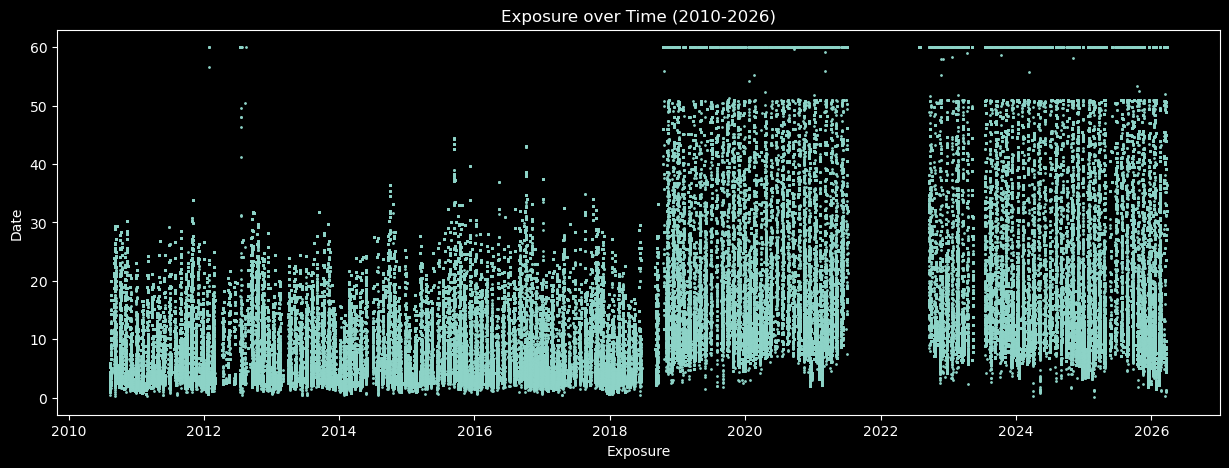

In [10]:
from matplotlib import pyplot as plt

plt.figure(figsize=(15, 5))
plt.scatter(ideal_df["timestamp"], ideal_df["exposure"], s=1)
plt.xlabel("Exposure")
plt.ylabel("Date")
plt.title("Exposure over Time (2010-2026)")
plt.show()

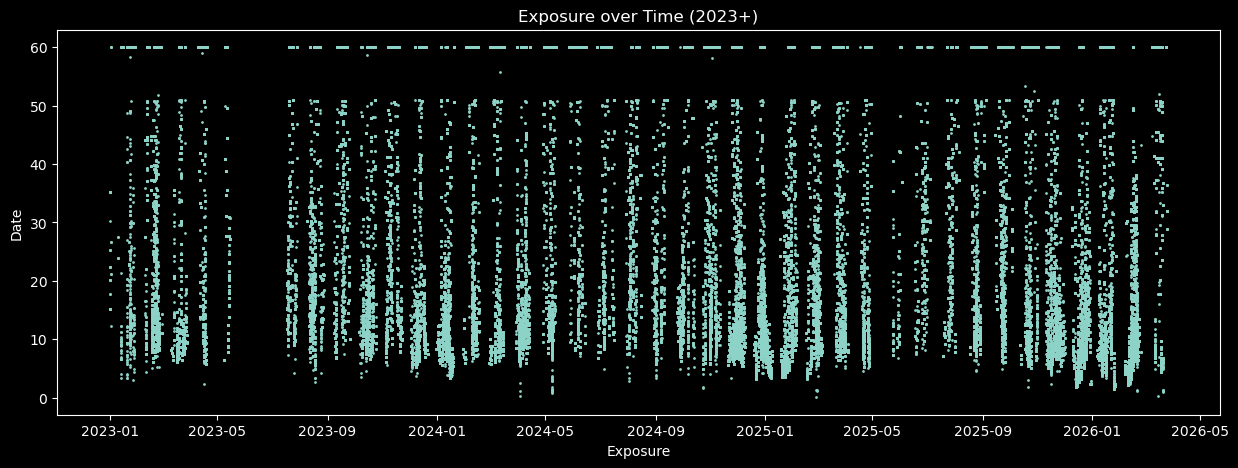

In [11]:
plt.figure(figsize=(15, 5))
plt.scatter(latest_df["timestamp"], latest_df["exposure"], s=1)
plt.xlabel("Exposure")
plt.ylabel("Date")
plt.title("Exposure over Time (2023+)")
plt.show()